# cluster the type A scans (1,2,3) and the type B scans (4,5)

In [1]:
import roifinder.src.roif_config
from roifinder.src.roif_config import *

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from matplotlib import rc
from matplotlib.widgets import LassoSelector
from matplotlib.path import Path
import seaborn as sns

import roifinder.src.xrf_roif_internals

from roifinder.src.xrf_roif_internals import *

import roifinder.src.xrfm_batches
from roifinder.src.xrfm_batches import *

from sklearn import metrics

import cv2

%matplotlib inline

2022-07-26 02:07:53.116923: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0


In [2]:
# Dice similarity function
def dice(pred, true, k = 1):
    intersection = np.sum(pred[true==k]) * 2.0
    dice = intersection / (np.sum(pred) + np.sum(true))
    return dice

# dice_score = dice(y_pred, y_true, k = 255) #k =255 or 1 or other target values
# print ("Dice Similarity: {}".format(dice_score))

def check_kmeans_class(dataframe, verbosity=False):
    '''
    inputs
    
    dataframe: pandas dataframe, must contain a column called 'Class' containing, kmeans.labels_ and 'K' column consisting of max amount of potassium values
    
    returns: dataframe is flipped, 0's are returned as 1 and 1's would be returned as 0's in the Class column of the dataframe to keep consistency.
    
    '''
    if verbosity != False:
        print('clustering algorithm assigned class to max K cell:', dataframe.iloc[dataframe['K'].idxmax()]['Class'])
        print('High K cell should be 1. Is it?', dataframe.iloc[dataframe['K'].idxmax()]['Class'] ==1 )

    
    if dataframe.iloc[dataframe['K'].idxmax()]['Class'] != 1:
        dataframe.loc[dataframe["Class"] == 1, "Class"] = -99
        dataframe.loc[dataframe["Class"] == 0, "Class"] = 88

        dataframe.loc[dataframe["Class"] == -99, "Class"] = 0
        dataframe.loc[dataframe["Class"] == 88, "Class"] = 1

        
    return dataframe



# define parameters

In [3]:
BASE_PATCH_WIDTH=32
selected_elm_maps=['Cu','Zn','Ca', 'K', 'P', 'S','Fe','Ni','Total_Fluorescence_Yield']
noise_type='none'
base_file_path = '../xrfdata/'

# coarse_scan_names = ['bnp_fly0032.mda.h5']


coarse_scan_names = ['scan1.mda.h5', 
                    'scan2.mda.h5',
                    'scan3.mda.h5',
                    'scan4.mda.h5',
                    'scan5.mda.h5']
                    


hdf5_string_list=['MAPS','MAPS','MAPS','MAPS','MAPS']
norm_ch_list=['US_IC','US_IC','US_IC','US_IC','US_IC']
selected_elm_maps_list=[selected_elm_maps,selected_elm_maps,selected_elm_maps,selected_elm_maps,selected_elm_maps]
noise_type_list = [noise_type,noise_type,noise_type,noise_type,noise_type]

# bin_conv_elm_list=['P', 'P', 'P', 'P', 'P']
bin_conv_elm_list=['KPSCa', 'KPSCa', 'KPSCa', 'KPSCa', 'KPSCa']
# bin_conv_elm_list=['TFY', 'TFY', 'TFY', 'TFY', 'TFY']

apply_gaussian_list=[False, False, False, False,False]
value_offset_list = [1e-12,1e-12,1e-12,1e-12,1e-12]
feature_mode_list=['max','max','max','max','max']


# assemble coarse scans

In [4]:
coarse_scans = XRFM_batch(base_file_path,
                  coarse_scan_names,
                 hdf5_string_list,
                 norm_ch_list,
                 selected_elm_maps_list,
                 noise_type_list,
                 bin_conv_elm_list,
                 value_offset_list,
                apply_gaussian_list,
                feature_mode_list,
                 BASE_PATCH_WIDTH,
                 print_pv=False,  
                 verbosity=False)

print('Bounding box width and height (pixels):' , BASE_PATCH_WIDTH)
print('Total extracted cells, features:', coarse_scans.X.shape)
print('Total extracted cell, cell size:', coarse_scans.X_bin.shape)


XRF ../xrfdata/scan1.mda.h5
['Cu', 'Zn', 'Ca', 'K', 'P', 'S', 'Fe', 'Ni', 'Total_Fluorescence_Yield']
max mode
(41, 14)
XRF ../xrfdata/scan2.mda.h5
['Cu', 'Zn', 'Ca', 'K', 'P', 'S', 'Fe', 'Ni', 'Total_Fluorescence_Yield']
max mode
(36, 14)
XRF ../xrfdata/scan3.mda.h5
['Cu', 'Zn', 'Ca', 'K', 'P', 'S', 'Fe', 'Ni', 'Total_Fluorescence_Yield']
max mode
(17, 14)
XRF ../xrfdata/scan4.mda.h5
['Cu', 'Zn', 'Ca', 'K', 'P', 'S', 'Fe', 'Ni', 'Total_Fluorescence_Yield']
max mode
(19, 14)
XRF ../xrfdata/scan5.mda.h5
['Cu', 'Zn', 'Ca', 'K', 'P', 'S', 'Fe', 'Ni', 'Total_Fluorescence_Yield']
max mode
(11, 14)
Bounding box width and height (pixels): 32
Total extracted cells, features: (124, 14)
Total extracted cell, cell size: (124, 32, 32)


/home/reshad812/anaconda3/lib/python3.8/site-packages/roifinder-1.0-py3.8.egg/roifinder/src/xrf_roif_internals.py:118: RuntimeWarning: divide by zero encountered in true_divide
/home/reshad812/anaconda3/lib/python3.8/site-packages/roifinder-1.0-py3.8.egg/roifinder/src/xrf_roif_internals.py:118: RuntimeWarning: invalid value encountered in true_divide


In [5]:
# coarse_scans.plot_coarse_binary_images()

# construct dataframe with all the extracted information from defined features
inside the beamtime_XRF_image_extract_cell_method

In [6]:
principalDf = pd.DataFrame(
             columns = ['Pixel_count', 'area'])


principalDf['area'] = coarse_scans.X[:,0]
principalDf['eccentricity'] = coarse_scans.X[:,1]
principalDf['equivalent_diameter'] = coarse_scans.X[:,2]
principalDf['major_axis_length'] = coarse_scans.X[:,3]
principalDf['minor_axis_length'] = coarse_scans.X[:,4]
principalDf['perimeter'] = coarse_scans.X[:,5]
principalDf['K'] = coarse_scans.X[:,6]
principalDf['P'] = coarse_scans.X[:,7]
principalDf['Ca'] = coarse_scans.X[:,8]
principalDf['Zn'] = coarse_scans.X[:,9]
principalDf['Fe'] = coarse_scans.X[:,10]
principalDf['Cu'] = coarse_scans.X[:,11]
principalDf['BFY'] = coarse_scans.X[:,12]
principalDf['Pixel_count'] = coarse_scans.X[:,13].astype(int)   #Pixel_count column must exist

#add res and origins to dataframe here
#convert from list
principalDf['x_res'] = coarse_scans.X_x_res
principalDf['y_res'] = coarse_scans.X_y_res
principalDf['avg_res'] = coarse_scans.X_avg_res
principalDf['x_origin'] = coarse_scans.X_x_origin
principalDf['y_origin'] = coarse_scans.X_y_origin
principalDf['x_motor'] = coarse_scans.X_x_motor
principalDf['y_motor'] = coarse_scans.X_y_motor
principalDf['xrf_file']=coarse_scans.X_xrf_track_files




#assign scan names in dataframe
number_of_cells = principalDf['xrf_file'].to_numpy().shape[0]
coarse_scan_name=[]
for idx in range(number_of_cells):

    coarse_scan_name.append(os.path.split(principalDf['xrf_file'].to_numpy()[idx])[1])
principalDf['scan_name'] =  np.array(coarse_scan_name)  


display(principalDf)

,Pixel_count,area,eccentricity,equivalent_diameter,major_axis_length,minor_axis_length,perimeter,K,P,Ca,...,BFY,x_res,y_res,avg_res,x_origin,y_origin,x_motor,y_motor,xrf_file,scan_name
0,5,0.3125,0.000000,0.630783,0.632456,0.632456,1.414214,0.000042,0.000038,0.000047,...,0.007212,0.25,0.256287,0.253143,110.674377,-661.065186,139.674377,-655.565186,../xrfdata/scan1.mda.h5,scan1.mda.h5
1,31,1.9375,0.926864,1.570637,2.566840,0.963588,5.242641,0.000042,0.000085,0.000074,...,0.007246,0.25,0.256287,0.253143,110.674377,-661.065186,175.174377,-654.565186,../xrfdata/scan1.mda.h5,scan1.mda.h5
2,5,0.3125,0.000000,0.630783,0.632456,0.632456,1.414214,0.000036,0.000046,0.000051,...,0.007115,0.25,0.256287,0.253143,110.674377,-661.065186,140.174377,-653.815186,../xrfdata/scan1.mda.h5,scan1.mda.h5
3,21,1.3125,0.945323,1.292721,2.313760,0.754599,3.828427,0.000069,0.000055,0.000065,...,0.007196,0.25,0.256287,0.253143,110.674377,-661.065186,121.424377,-652.315186,../xrfdata/scan1.mda.h5,scan1.mda.h5
4,11,0.6875,0.755929,0.935603,1.128152,0.738549,2.414214,0.000046,0.000057,0.000034,...,0.007210,0.25,0.256287,0.253143,110.674377,-661.065186,139.174377,-650.565186,../xrfdata/scan1.mda.h5,scan1.mda.h5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,5,0.3125,0.000000,0.630783,0.632456,0.632456,1.414214,0.000017,0.000139,0.000079,...,0.002593,0.25,0.245728,0.247864,-73.469749,-1059.976318,-24.719749,-1038.726318,../xrfdata/scan5.mda.h5,scan5.mda.h5
120,5,0.3125,0.000000,0.630783,0.632456,0.632456,1.414214,0.000024,0.000138,0.000091,...,0.002823,0.25,0.245728,0.247864,-73.469749,-1059.976318,-25.219749,-1037.226318,../xrfdata/scan5.mda.h5,scan5.mda.h5
121,5,0.3125,0.000000,0.630783,0.632456,0.632456,1.414214,0.000009,0.000054,0.000065,...,0.002072,0.25,0.245728,0.247864,-73.469749,-1059.976318,-50.969749,-1035.226318,../xrfdata/scan5.mda.h5,scan5.mda.h5
122,21,1.3125,0.941908,1.292721,2.248000,0.755036,4.181981,0.000017,0.000119,0.000056,...,0.001975,0.25,0.245728,0.247864,-73.469749,-1059.976318,-58.969749,-1034.226318,../xrfdata/scan5.mda.h5,scan5.mda.h5


# remove extracted cells that contain less than certain amount of pixels

In [7]:
secondaryDf=remove_artifacts(principalDf, remove_count = 8)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(secondaryDf)

# secondaryDf.head()

/home/reshad812/anaconda3/lib/python3.8/site-packages/roifinder-1.0-py3.8.egg/roifinder/src/xrf_roif_internals.py:974: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  secondaryDf['original index'] = secondaryDf.index.to_numpy()


,Pixel_count,area,eccentricity,equivalent_diameter,major_axis_length,minor_axis_length,perimeter,K,P,Ca,Zn,Fe,Cu,BFY,x_res,y_res,avg_res,x_origin,y_origin,x_motor,y_motor,xrf_file,scan_name,original index
0,31,1.9375,0.926864,1.570637,2.566840,0.963588,5.242641,0.000042,0.000085,0.000074,0.000071,0.000048,0.000072,0.007246,0.25,0.256287,0.253143,110.674377,-661.065186,175.174377,-654.565186,../xrfdata/scan1.mda.h5,scan1.mda.h5,1
1,21,1.3125,0.945323,1.292721,2.313760,0.754599,3.828427,0.000069,0.000055,0.000065,0.000051,0.000035,0.000046,0.007196,0.25,0.256287,0.253143,110.674377,-661.065186,121.424377,-652.315186,../xrfdata/scan1.mda.h5,scan1.mda.h5,3
2,11,0.6875,0.755929,0.935603,1.128152,0.738549,2.414214,0.000046,0.000057,0.000034,0.000053,0.000040,0.000037,0.007210,0.25,0.256287,0.253143,110.674377,-661.065186,139.174377,-650.565186,../xrfdata/scan1.mda.h5,scan1.mda.h5,4
3,42,2.6250,0.926738,1.828183,3.026790,1.137187,6.389087,0.000054,0.000088,0.000078,0.000055,0.000042,0.000059,0.007298,0.25,0.256287,0.253143,110.674377,-661.065186,178.674377,-648.065186,../xrfdata/scan1.mda.h5,scan1.mda.h5,5
4,18,1.1250,0.722659,1.196827,1.423347,0.983824,3.267767,0.000042,0.000064,0.000100,0.000070,0.000044,0.000052,0.007146,0.25,0.256287,0.253143,110.674377,-661.065186,126.924377,-648.065186,../xrfdata/scan1.mda.h5,scan1.mda.h5,6
5,49,3.0625,0.925859,1.974664,3.245418,1.226342,7.035534,0.000044,0.000089,0.000127,0.000077,0.000041,0.000051,0.007242,0.25,0.256287,0.253143,110.674377,-661.065186,152.424377,-647.565186,../xrfdata/scan1.mda.h5,scan1.mda.h5,7
6,95,5.9375,0.993093,2.749520,8.450952,0.991554,15.906854,0.000055,0.000079,0.000064,0.000049,0.000051,0.000058,0.007374,0.25,0.256287,0.253143,110.674377,-661.065186,134.924377,-643.565186,../xrfdata/scan1.mda.h5,scan1.mda.h5,8
7,38,2.3750,0.927087,1.738949,2.844144,1.066118,5.974874,0.000055,0.000073,0.000113,0.000045,0.000046,0.000046,0.007229,0.25,0.256287,0.253143,110.674377,-661.065186,142.924377,-644.565186,../xrfdata/scan1.mda.h5,scan1.mda.h5,9
8,47,2.9375,0.984730,1.933944,4.921048,0.856704,7.303301,0.000050,0.000099,0.000051,0.000058,0.000039,0.000058,0.007299,0.25,0.256287,0.253143,110.674377,-661.065186,173.174377,-644.065186,../xrfdata/scan1.mda.h5,scan1.mda.h5,10
9,50,3.1250,0.977717,1.994711,4.549151,0.955001,8.010408,0.000050,0.000064,0.000114,0.000078,0.000044,0.000051,0.007258,0.25,0.256287,0.253143,110.674377,-661.065186,112.674377,-642.565186,../xrfdata/scan1.mda.h5,scan1.mda.h5,11


# Construct the features for PCA

In [8]:

mod_X = np.asarray([
    secondaryDf['area'],secondaryDf['eccentricity'],
    secondaryDf['K'],secondaryDf['P'],secondaryDf['Ca'],secondaryDf['Zn'],secondaryDf['Fe']
               ]).T

print('Cells, features', mod_X.shape)

Cells, features (106, 7)


# perform PCA

PC = f('area','eccentricity','equiv. dia.','major length','minor length','perimeter',
        'K','P','Ca','Zn',
         'Fe')
         

Cells, PCs (106, 2)
singular_values_: [14.95508058 12.83315463]
explained_variance: [2.13004224 1.56847484]
components: [[ 0.28432613  0.41563912 -0.21150339  0.44361483  0.55675397  0.44079471
   0.02449505]
 [ 0.3784722   0.18879809  0.63311783 -0.42938884  0.10842451  0.15190484
   0.44840847]]


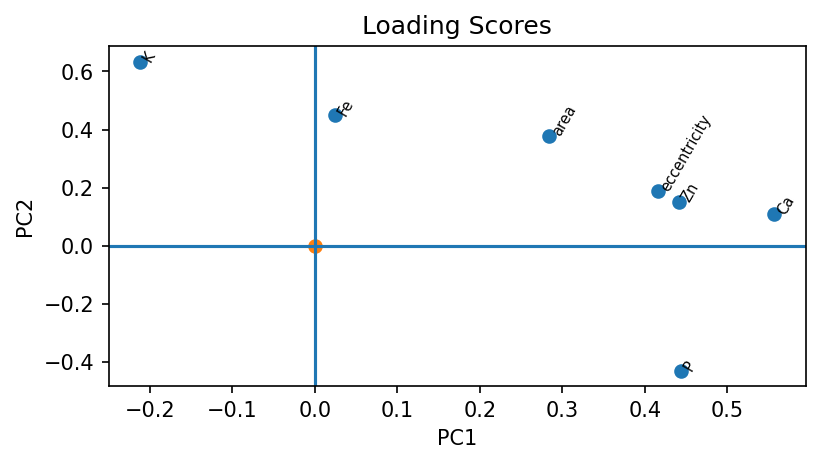

<Figure size 432x288 with 0 Axes>

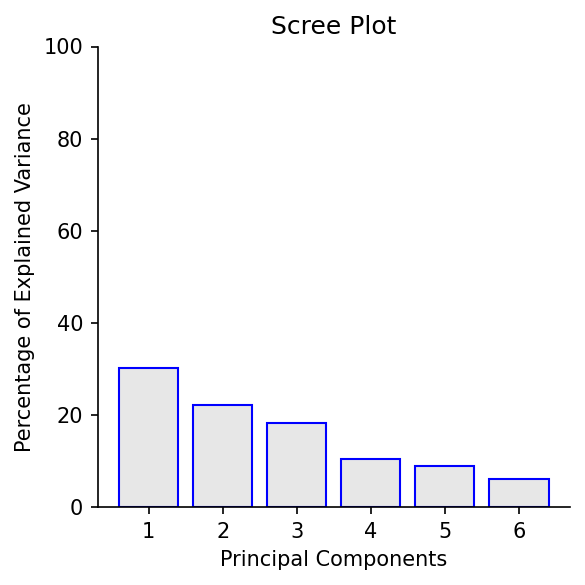

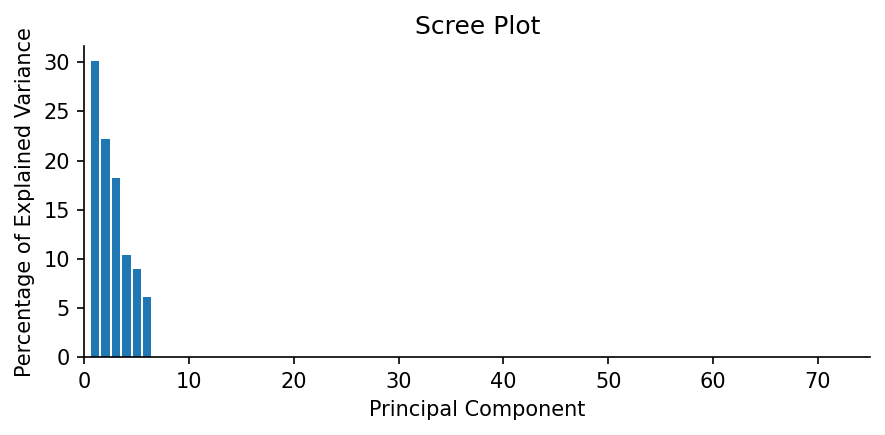

/tmp/ipykernel_1001059/2612577500.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  secondaryDf['PC1']=principalComponents[:,0]
/tmp/ipykernel_1001059/2612577500.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  secondaryDf['PC2']=principalComponents[:,1]


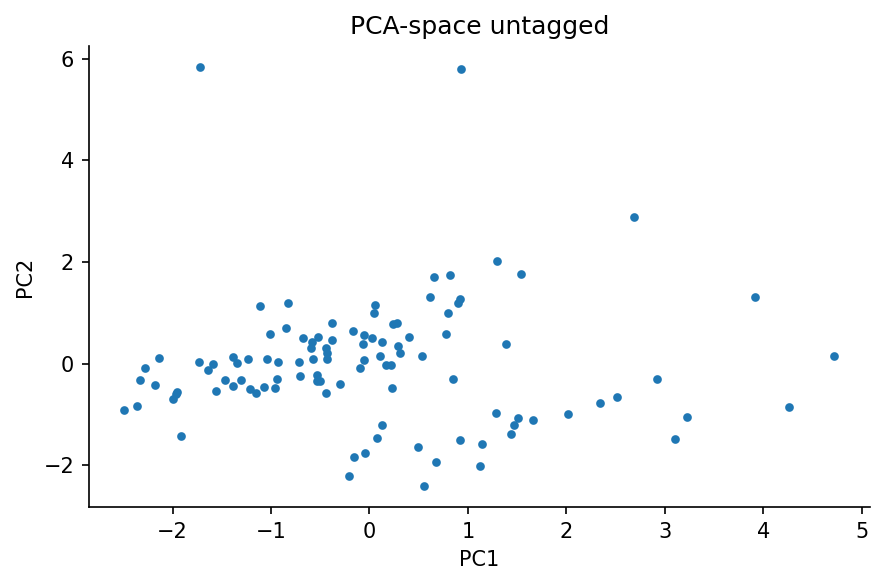

In [9]:
%matplotlib inline

# feature_names = ['area','eccentricity','equiv. dia.','major length','minor length','perimeter',
#         'K','P','Ca','Zn',
#          'Fe']

feature_names = ['area','eccentricity','K','P','Ca','Zn','Fe']


principalComponents, loading_scores = XRF_PCA(mod_X, feature_names, high_comp=6, n_components=2, 
                                              annot_txt_size=7, dpi =150, marker_size=3,save_plots=True)

#assign PC values to dataframe
secondaryDf['PC1']=principalComponents[:,0]
secondaryDf['PC2']=principalComponents[:,1]
# secondaryDf['PC3']=principalComponents[:,2]



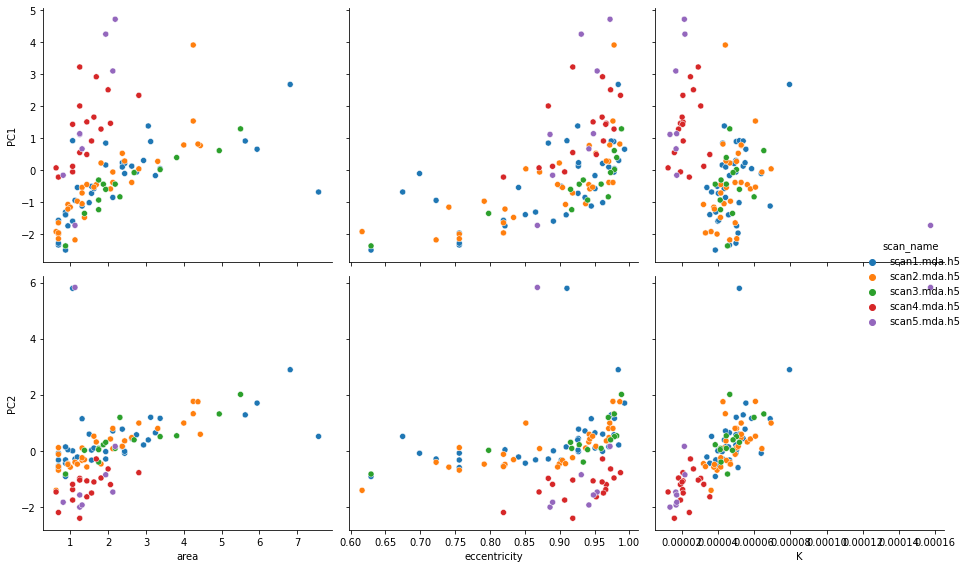

In [10]:
feature_list = ["area", "eccentricity", "K"]
PC_names=["PC1", "PC2"]    
view_PC_feature_relation(secondaryDf,PC_names, feature_list, hue = 'scan_name',save_plots=True )

In [11]:
secondaryDf.head()

,Pixel_count,area,eccentricity,equivalent_diameter,major_axis_length,minor_axis_length,perimeter,K,P,Ca,...,avg_res,x_origin,y_origin,x_motor,y_motor,xrf_file,scan_name,original index,PC1,PC2
0,31,1.9375,0.926864,1.570637,2.566840,0.963588,5.242641,0.000042,0.000085,0.000074,...,0.253143,110.674377,-661.065186,175.174377,-654.565186,../xrfdata/scan1.mda.h5,scan1.mda.h5,1,0.166639,-0.033176
1,21,1.3125,0.945323,1.292721,2.313760,0.754599,3.828427,0.000069,0.000055,0.000065,...,0.253143,110.674377,-661.065186,121.424377,-652.315186,../xrfdata/scan1.mda.h5,scan1.mda.h5,3,-1.116131,1.140094
2,11,0.6875,0.755929,0.935603,1.128152,0.738549,2.414214,0.000046,0.000057,0.000034,...,0.253143,110.674377,-661.065186,139.174377,-650.565186,../xrfdata/scan1.mda.h5,scan1.mda.h5,4,-2.334037,-0.332396
3,42,2.6250,0.926738,1.828183,3.026790,1.137187,6.389087,0.000054,0.000088,0.000078,...,0.253143,110.674377,-661.065186,178.674377,-648.065186,../xrfdata/scan1.mda.h5,scan1.mda.h5,5,0.131042,0.433937
4,18,1.1250,0.722659,1.196827,1.423347,0.983824,3.267767,0.000042,0.000064,0.000100,...,0.253143,110.674377,-661.065186,126.924377,-648.065186,../xrfdata/scan1.mda.h5,scan1.mda.h5,6,-0.939156,-0.295826


# tag based off of experiments, so we can see the effect of sample prep.

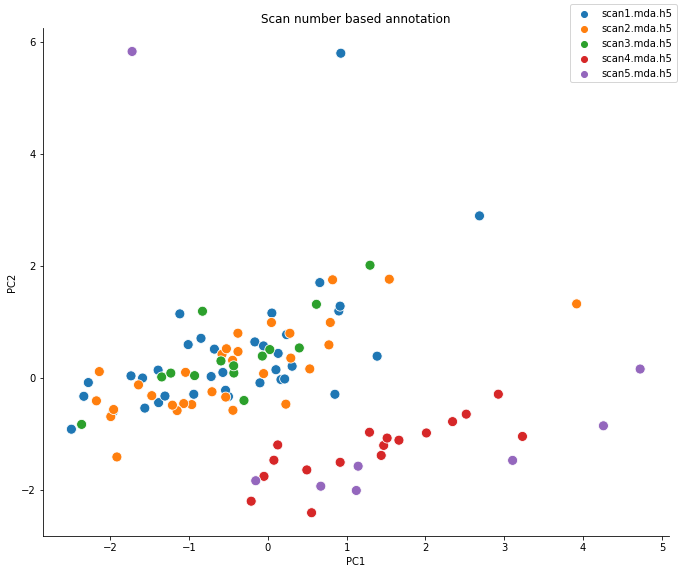

In [12]:
pp = sns.pairplot(data=secondaryDf,
                  y_vars=['PC2'],
                  x_vars=['PC1'],
                  kind = 'scatter', 
                 diag_kind='hist', corner = 'True', hue='scan_name', height=8,plot_kws={"s": 100}
                 )
leg_handles = pp._legend_data.values()
leg_labels = pp._legend_data.keys()
pp.fig.legend(handles=leg_handles, labels=leg_labels, loc='upper right', ncol=1)
pp._legend.remove() # remove existing legend
pp.set(xlabel='PC1',
       ylabel='PC2',
       title='Scan number based annotation')
plt.tight_layout()
plt.savefig('../figures/pc_space_scan_tagged.jpg')

In [13]:
# print(secondaryDf[['area','eccentricity', 'K','P','Ca','Zn','Fe']].to_latex(index=True))  

Length true list:  81
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
dict_keys(['False', 'True'])


/tmp/ipykernel_1001059/2911525628.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  secondaryDf['text_labels'] = text_labels


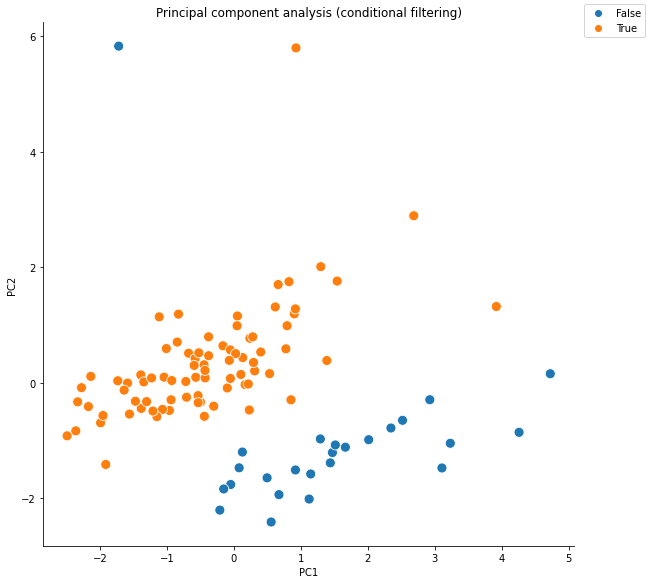

In [14]:
# condition check

labels = [0] * mod_X.shape[0]
text_labels=labels
True_list = secondaryDf.loc[
    (secondaryDf['scan_name']=='scan1.mda.h5') | 
    (secondaryDf['scan_name']=='scan2.mda.h5') | 
    (secondaryDf['scan_name']=='scan3.mda.h5')  
   ].index.tolist()    
    
print('Length true list: ', len(True_list) )

for idx in True_list:
    labels[idx]=1 
print(labels)


y_dh=np.array(labels).astype(int)    #domain h labels
y=labels

RANGE=mod_X.shape[0]

for idx in range(RANGE):
    if text_labels[idx] ==0:
        text_labels[idx] = False
    if text_labels[idx] ==1:
        text_labels[idx] = True
        
secondaryDf['text_labels'] = text_labels

pp = sns.pairplot(data=secondaryDf,
                  y_vars=['PC2'],
                  x_vars=['PC1'],
                  kind = 'scatter', 
                 diag_kind='hist', corner = 'True', hue='text_labels',  height=8,plot_kws={"s": 100}
                 )
leg_handles = pp._legend_data.values()
leg_labels = pp._legend_data.keys()

pp.fig.legend(handles=leg_handles, labels=leg_labels, loc='upper right', ncol=1)
pp._legend.remove() # remove existing legend
print(leg_labels)

pp.set(xlabel='PC1',
       ylabel='PC2',
       title='Principal component analysis (conditional filtering)')



In [15]:
y_dh

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [16]:
secondaryDf['y_dh']=y_dh.astype(int)

/tmp/ipykernel_1001059/587906483.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  secondaryDf['y_dh']=y_dh.astype(int)


# sample 5%, 10%, 20%, 50% cells from each type and cluster using k-means, calculate dice score.

### (4,1) , (8,3), (16,5),  (41,13)

Date: April 18


Dice Similarity: 0.9879518072289156


Text(0, 0.5, 'PC2')

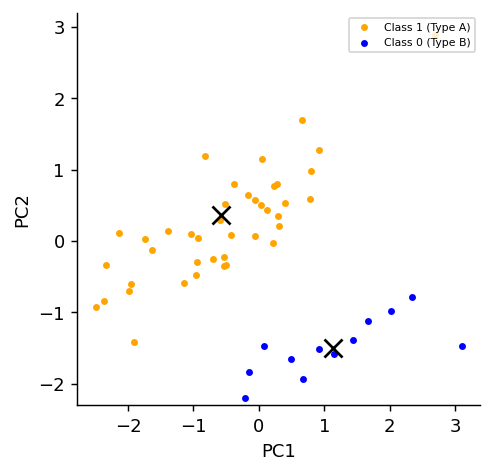

In [17]:
# keep 4  constant type A cell vary type B cells
type_B_Df=secondaryDf[secondaryDf['y_dh']==0]
type_A_Df=secondaryDf[secondaryDf['y_dh']==1]

# sample 1 Type A cells 

rand_index_list = []
adj_rand_index_list = []
dice_score_list = []


sampled_Type_A_Df=type_A_Df.sample(n=41, replace=False, random_state=0)
sampled_Type_B_Df=type_B_Df.sample(n=13, replace=False, random_state=0)

#     sampled_Df=sampled_Type_A_Df
sampled_Df =pd.concat([sampled_Type_A_Df, sampled_Type_B_Df], axis = 0)

sampled_Df.reset_index(drop=True, inplace=True)



kmeans = KMeans(init="k-means++",n_clusters = 2, n_init=200, random_state = 42).fit(sampled_Df[['PC1','PC2']].to_numpy())
inertia=kmeans.inertia_
sampled_Df['Class'] = kmeans.labels_
sampled_Df = check_kmeans_class(sampled_Df)


# rand_index=metrics.rand_score(sampled_Df['y_dh'].to_numpy(), kmeans.labels_)
# rand_index_list.append(rand_index)
# #     print('unadjusted rand index [0,1]:',rand_index)
# adj_rand_index=metrics.adjusted_rand_score(sampled_Df['y_dh'].to_numpy(), kmeans.labels_)
# #     print('adjusted rand index [-1,1]:',adj_rand_index)
# adj_rand_index_list.append(adj_rand_index)

dice_score = dice(sampled_Df['Class'].to_numpy(), sampled_Df['y_dh'].to_numpy(), k = 1) 
print ("Dice Similarity: {}".format(dice_score))
dice_score_list.append(dice_score)


# pp = sns.pairplot(data=sampled_Df,
#                   y_vars=['PC2'],
#                   x_vars=['PC1'],
#                   kind = 'scatter', 
#                  diag_kind='hist', corner = 'True', hue='Class', height=8,plot_kws={"s": 100}
#                  )
# leg_handles = pp._legend_data.values()
# leg_labels = pp._legend_data.keys()
# pp.fig.legend(handles=leg_handles, labels=leg_labels, loc='upper right', ncol=1)
# pp._legend.remove() # remove existing legend
# pp.set(xlabel='PC1',
#        ylabel='PC2',
#        title='50% sampled data from each type')

# plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], marker='x',s=1000, facecolors='black')
# plt.tight_layout()
# plt.savefig('../figures/pc_space_km_clustered_10.jpg')


plt.figure(figsize=(4,4),dpi=130)

plt.scatter(sampled_Df[sampled_Df['Class']== 1]['PC1'].to_numpy(),
            sampled_Df[sampled_Df['Class']== 1]['PC2'].to_numpy(),
            color='orange',s=8, label='Class 1 (Type A)')

plt.scatter(sampled_Df[sampled_Df['Class']== 0]['PC1'].to_numpy(),
            sampled_Df[sampled_Df['Class']== 0]['PC2'].to_numpy(),
            color='blue',s=8, label='Class 0 (Type B)')
# plt.title('100% sampled data from each type')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], marker='x',s=100, facecolors='black')

plt.legend(loc=1, prop={'size': 6})

plt.ylim([-2.3, 3.2])
plt.xlabel('PC1')
plt.ylabel('PC2')





Dice Similarity: 0.9879518072289156


Text(0, 0.5, 'PC2')

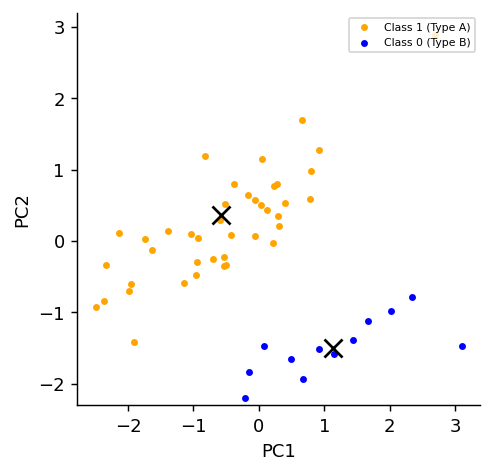

In [18]:
percentage=50

# keep 4  constant type A cell vary type B cells
type_B_Df=secondaryDf[secondaryDf['y_dh']==0]
type_A_Df=secondaryDf[secondaryDf['y_dh']==1]

# sample 1 Type A cells 

rand_index_list = []
adj_rand_index_list = []
dice_score_list = []


sampled_Type_A_Df=type_A_Df.sample(n=int(math.ceil(percentage*type_A_Df.index.to_numpy().shape[0]/100)), replace=False, random_state=0)
sampled_Type_B_Df=type_B_Df.sample(n=int(math.ceil(percentage*type_B_Df.index.to_numpy().shape[0]/100)), replace=False, random_state=0)

#     sampled_Df=sampled_Type_A_Df
sampled_Df =pd.concat([sampled_Type_A_Df, sampled_Type_B_Df], axis = 0)

sampled_Df.reset_index(drop=True, inplace=True)



kmeans = KMeans(init="k-means++",n_clusters = 2, n_init=200, random_state = 42).fit(sampled_Df[['PC1','PC2']].to_numpy())
inertia=kmeans.inertia_
sampled_Df['Class'] = kmeans.labels_
sampled_Df = check_kmeans_class(sampled_Df)


dice_score = dice(sampled_Df['Class'].to_numpy(), sampled_Df['y_dh'].to_numpy(), k = 1) 
print ("Dice Similarity: {}".format(dice_score))
dice_score_list.append(dice_score)




plt.figure(figsize=(4,4),dpi=130)

plt.scatter(sampled_Df[sampled_Df['Class']== 1]['PC1'].to_numpy(),
            sampled_Df[sampled_Df['Class']== 1]['PC2'].to_numpy(),
            color='orange',s=8, label='Class 1 (Type A)')

plt.scatter(sampled_Df[sampled_Df['Class']== 0]['PC1'].to_numpy(),
            sampled_Df[sampled_Df['Class']== 0]['PC2'].to_numpy(),
            color='blue',s=8, label='Class 0 (Type B)')
# plt.title('100% sampled data from each type')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], marker='x',s=100, facecolors='black')

plt.legend(loc=1, prop={'size': 6})

plt.ylim([-2.3, 3.2])
plt.xlabel('PC1')
plt.ylabel('PC2')





In [19]:


type_B_Df=secondaryDf[secondaryDf['y_dh']==0]
type_A_Df=secondaryDf[secondaryDf['y_dh']==1]

percentages = []
dice_score_list = []

sampling_number = 1000
for p in range(5, 95, 10):
    dice_scores = []
    for i in range(sampling_number):
        sampled_Type_A_Df=type_A_Df.sample(n=int(math.ceil(p*type_A_Df.index.to_numpy().shape[0]/100)), replace=False)
        sampled_Type_B_Df=type_B_Df.sample(n=int(math.ceil(p*type_B_Df.index.to_numpy().shape[0]/100)), replace=False)
        sampled_Df =pd.concat([sampled_Type_A_Df, sampled_Type_B_Df], axis = 0)
        sampled_Df.reset_index(drop=True, inplace=True)



        kmeans = KMeans(init="k-means++",n_clusters = 2, n_init=200, random_state = 42).fit(sampled_Df[['PC1','PC2']].to_numpy())
        inertia=kmeans.inertia_
        sampled_Df['Class'] = kmeans.labels_
        sampled_Df = check_kmeans_class(sampled_Df)


        dice_score = dice(sampled_Df['Class'].to_numpy(), sampled_Df['y_dh'].to_numpy(), k = 1) 
        dice_scores.append(dice_score)
        
        
#     print ("Dice Similarity: {}".format(dice_score))
    dice_score_list.append(sum(dice_scores)/sampling_number)
    percentages.append(p)


Text(0, 0.5, 'Average Dice Score over 1000 trials')

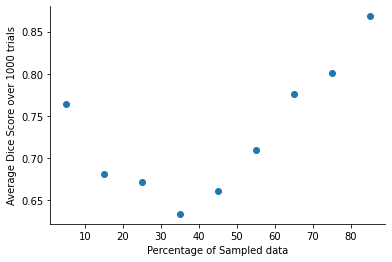

In [20]:
plt.scatter(percentages, dice_score_list)
plt.xlabel('Percentage of Sampled data')
plt.ylabel('Average Dice Score over 1000 trials')

In [21]:
percentages

[5, 15, 25, 35, 45, 55, 65, 75, 85]

In [22]:
dice_score_list

[0.7637541125541141,
 0.6812550941678227,
 0.6715672115776536,
 0.6339486471924493,
 0.660861870874271,
 0.7092763776953861,
 0.7759233303839167,
 0.8003752718236209,
 0.8681987902794541]

In [23]:
result = pd.DataFrame()
result['percentage'] = percentages
result['dice_score'] = dice_score_list
result['count_type_A'] = (result['percentage']*type_A_Df.index.to_numpy().shape[0]/100).apply(np.ceil)
result['count_type_B'] = (result['percentage']*type_B_Df.index.to_numpy().shape[0]/100).apply(np.ceil)
result['total cells'] = result['count_type_A'] + result['count_type_B']

In [24]:
print(result.to_latex(index = False))

\begin{tabular}{rrrrr}
\toprule
 percentage &  dice\_score &  count\_type\_A &  count\_type\_B &  total cells \\
\midrule
          5 &    0.763754 &           5.0 &           2.0 &          7.0 \\
         15 &    0.681255 &          13.0 &           4.0 &         17.0 \\
         25 &    0.671567 &          21.0 &           7.0 &         28.0 \\
         35 &    0.633949 &          29.0 &           9.0 &         38.0 \\
         45 &    0.660862 &          37.0 &          12.0 &         49.0 \\
         55 &    0.709276 &          45.0 &          14.0 &         59.0 \\
         65 &    0.775923 &          53.0 &          17.0 &         70.0 \\
         75 &    0.800375 &          61.0 &          19.0 &         80.0 \\
         85 &    0.868199 &          69.0 &          22.0 &         91.0 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_1001059/4171187360.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(result.to_latex(index = False))
